# 1. Importações

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2 Tratamento

### 2.1 Limpeza por Variáveis Críticas

In [56]:
df_raw = pd.read_csv("dataset.csv", sep=";", low_memory=False)
print(f"Dimensões originais do dataset: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas\n")

# Remove observações com nulos nas variáveis vitais de categorização.
critical_cols = ['Data_da_Ocorrencia', 'Classificacao_da_Ocorrencia', 'Operacao']
df_clean = df_raw.dropna(subset=critical_cols).copy()

Dimensões originais do dataset: 5021 linhas e 45 colunas



### 2.2 Tratamento Temporal

In [57]:
# Extraindo o ano a partir da coluna de data.
# Certificando-se de que a coluna está no formato datetime.
df_clean['Data_da_Ocorrencia'] = pd.to_datetime(df_clean['Data_da_Ocorrencia'], errors='coerce')
df_clean['ANO_OCORRENCIA'] = df_clean['Data_da_Ocorrencia'].dt.year

# Filtra os anos que fornecem dados mais consistentes.
df_clean = df_clean[(df_clean['ANO_OCORRENCIA'] >= 1998) & (df_clean['ANO_OCORRENCIA'] <= 2022)].copy()

print(f"Dimensões do dataset tratado: {df_clean.shape[0]} linhas\n")
df_clean.head()

Dimensões do dataset tratado: 4441 linhas



,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO,ANO_OCORRENCIA
0,5015,/2005,JOSE SEVERINO ENEAS CANDIDO,Acidente,2005-03-27,NaN,NaN,CE,Nordeste,NaN,...,0.0,0.0,EMB-720C,L1P,PA32,1542.0,7.0,NEIVA,verdadeiro,2005
1,5014,/2005,STILUS TAXI AEREO LTDA,Acidente,2005-03-19,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,EMB-721C,L1P,P32R,1633.0,7.0,NEIVA,verdadeiro,2005
2,5013,/2005,AGROPENA AVIACAO AGRICOLA LTDA,Acidente,2005-03-18,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,PA-25-260,L1P,PA25,1315.0,1.0,PIPER AIRCRAFT,verdadeiro,2005
3,5023,/2005,LEONARDO SUBTIL MARTINS ALMEIDA,Acidente,2005-05-27,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,140A,L1P,C140,680.0,2.0,CESSNA AIRCRAFT,verdadeiro,2005
4,5012,/2005,MARISA MENDES DE OLIVEIRA,Acidente,2005-03-18,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,172,L1P,C172,998.0,4.0,CESSNA AIRCRAFT,verdadeiro,2005


### 2.3 Agrupamento de Segmento de Aviação

In [58]:
# Identifica os 4 maiores segmentos
critical_sectors = ['Voo Privado', 'Operação Agrícola', 'Voo de Instrução', 'Táxi Aéreo']
# Tudo o que não for top 4 vira "OUTROS SEGMENTOS"
df_clean['SEGMENTO_AGRUPADO'] = df_clean['Operacao'].apply(
    lambda x: x if x in critical_sectors else 'Outros Segmentos'
)

# 3 Análise Unidimensional Qualitativa

### 3.1 Distribuição de Frequência para Classificação da Ocorrência

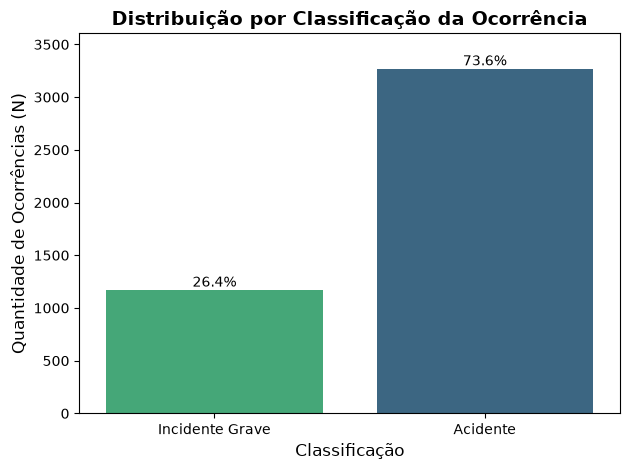

In [65]:
fig, ax = plt.subplots()

order = (
    df_clean['Classificacao_da_Ocorrencia']
    .value_counts()
    .sort_values()
    .index
)
sns.countplot(data=df_clean, x='Classificacao_da_Ocorrencia', hue='Classificacao_da_Ocorrencia', order=order, palette='viridis', legend=False, ax=ax)
ax.set_title('Distribuição por Classificação da Ocorrência', fontsize=14, fontweight='bold')
ax.set_xlabel('Classificação', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências (N)', fontsize=12)

ax.set_ylim(top=ax.get_ylim()[1] * 1.05)
length = len(df_clean)
for bar in ax.patches:
    height = bar.get_height()
    percent = 100 * height / length

    ax.annotate(
        f'{percent:.1f}%',
        (bar.get_x() + bar.get_width()/2, height),
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

### 3.2 Distribuição de Frequência para Segmento de Aviação

In [60]:
freq_seg_abs = df_clean['Operacao'].value_counts()
freq_seg_rel = df_clean['Operacao'].value_counts(normalize=True) * 100

tab_segmento = pd.DataFrame({
    'Frequência Absoluta (N)': freq_seg_abs,
    'Frequência Relativa (%)': freq_seg_rel
})
print(tab_segmento.round(2))
print("\n" + "="*50 + "\n")

                        Frequência Absoluta (N)  Frequência Relativa (%)
Operacao                                                                
Voo Privado                                2059                    46.36
Operação Agrícola                           751                    16.91
Voo de Instrução                            705                    15.87
Táxi Aéreo                                  492                    11.08
Voo Regular                                 141                     3.17
Operação Pública                            119                     2.68
Operação Especializada                       98                     2.21
Voo Experimental                             44                     0.99
Desconhecida                                 12                     0.27
Voo não regular                               9                     0.20
Operação Policial                             8                     0.18
Operação Militar                              3    

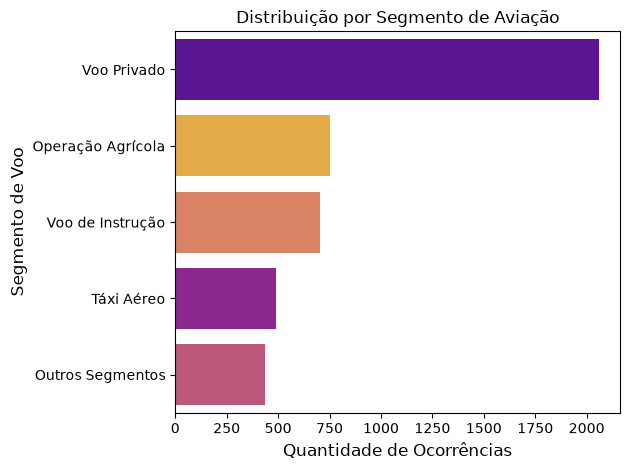

In [61]:
fig, ax = plt.subplots()

segmentos = df_clean['SEGMENTO_AGRUPADO'].value_counts().index
sns.countplot(data=df_clean,
              y='SEGMENTO_AGRUPADO', hue='SEGMENTO_AGRUPADO', palette='plasma', order=segmentos, legend=False)

ax.set_title('Distribuição por Segmento de Aviação')
ax.set_xlabel('Quantidade de Ocorrências', fontsize=12)
ax.set_ylabel('Segmento de Voo', fontsize=12)

plt.tight_layout()
plt.show()

### 3.3 Evolução Temporal

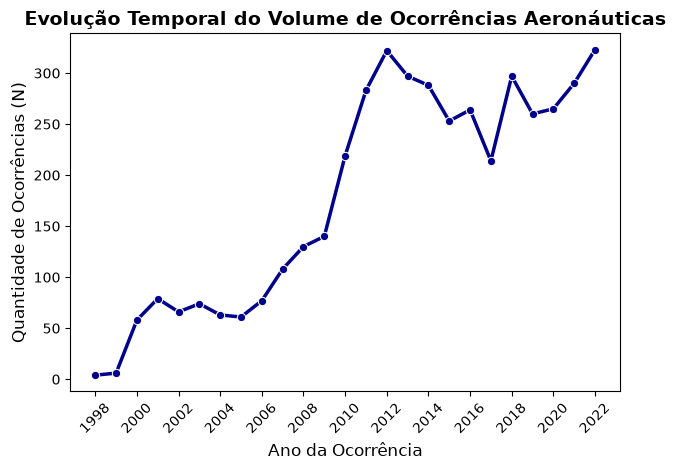

In [70]:
fig, ax = plt.subplots()
freq_year_abs = df_clean['ANO_OCORRENCIA'].value_counts().sort_index()
sns.lineplot(x=freq_year_abs.index, y=freq_year_abs.values, marker='o', color='darkblue', linewidth=2.5, ax=ax)

ax.set_title('Evolução Temporal do Volume de Ocorrências Aeronáuticas', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano da Ocorrência', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências (N)', fontsize=12)

plt.xticks(range(1998, 2023, 2), rotation=45)
plt.tight_layout()
plt.show()